# Ejercicio Módulo 5 - Dataset Swiss
**Inteligencia Artificial - CEIA - FIUBA**

**Daniel Alejandro Acero Varela**

Para aprender sobre regresión, vamos a utilizar un dataset clásico llamado Swiss, que proviene originalmente del lenguaje R. Este dataset contiene datos socioeconómicos de 47 provincias suizas a fines del siglo XIX. Cada fila representa una provincia, y las variables reflejan características demográficas y sociales relevantes para ese contexto histórico.

## Variables

- `Location`: Provincia donde se midieron los datos.
- `Fertility`: Tasa de fertilidad (número promedio de hijos por mujer)
- `Agriculture`:` Porcentaje de hombres ocupados en agricultura
- `Examination`: Porcentaje de hombres que completaron exámenes de educación superior
- `Education`: Nivel promedio de educación (escala arbitraria)
- `Catholic`: Porcentaje de población católica
- `Infant.Mortality`: Tasa de mortalidad infantil (por cada 1000 nacidos vivos)

## Que queremos predecir?

Vamos a utilizar este dataset para predecir la tasa de fertilidad en cada provincia mediante diferentes métodos de regresión.

---

Siguiendo el procedimiento típico de Machine Learning, vamos a leer los datos y separarlos en los datasets de entrenamiento y testeo utilizando Scikit-Learn...

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("swiss.csv")

df.head()

,Location,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
0,Courtelary,80.2,17.0,15,12,9.96,22.2
1,Delemont,83.1,45.1,6,9,84.84,22.2
2,Franches-Mnt,92.5,39.7,5,5,93.40,20.2
3,Moutier,85.8,36.5,12,7,33.77,20.3
4,Neuveville,76.9,43.5,17,15,5.16,20.6


In [52]:
df.tail()

,Location,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
42,Val de Ruz,77.6,37.6,15,7,4.97,20.0
43,ValdeTravers,67.6,18.7,25,7,8.65,19.5
44,V. De Geneve,35.0,1.2,37,53,42.34,18.0
45,Rive Droite,44.7,46.6,16,29,50.43,18.2
46,Rive Gauche,42.8,27.7,22,29,58.33,19.3


In [60]:
df.describe(include='O')

,Location
count,47
unique,47
top,Courtelary
freq,1


In [65]:
print(f"Tenemos {df.Location.nunique()} categorías en 'Location'. Estas son:")
df["Location"].unique()

Tenemos 47 categorías en 'Location'. Estas son:


array(['Courtelary', 'Delemont', 'Franches-Mnt', 'Moutier', 'Neuveville',
       'Porrentruy', 'Broye', 'Glane', 'Gruyere', 'Sarine', 'Veveyse',
       'Aigle', 'Aubonne', 'Avenches', 'Cossonay', 'Echallens',
       'Grandson', 'Lausanne', 'La Vallee', 'Lavaux', 'Morges', 'Moudon',
       'Nyone', 'Orbe', 'Oron', 'Payerne', "Paysd'enhaut", 'Rolle',
       'Vevey', 'Yverdon', 'Conthey', 'Entremont', 'Herens', 'Martigwy',
       'Monthey', 'St Maurice', 'Sierre', 'Sion', 'Boudry',
       'La Chauxdfnd', 'Le Locle', 'Neuchatel', 'Val de Ruz',
       'ValdeTravers', 'V. De Geneve', 'Rive Droite', 'Rive Gauche'],
      dtype=object)

In [2]:
print(f"Tenemos {df.shape[0]} observaciones")

Tenemos 47 observaciones


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          47 non-null     object 
 1   Fertility         47 non-null     float64
 2   Agriculture       47 non-null     float64
 3   Examination       47 non-null     int64  
 4   Education         47 non-null     int64  
 5   Catholic          47 non-null     float64
 6   Infant.Mortality  47 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 2.7+ KB


Obtenemos la variable objetivo (`Fertility`) y, por otro lado, los atributos (quitamos `Location` ya que no es un atributo numérico relevante para la regresión)

In [3]:
X = df.drop(["Fertility", "Location"], axis=1) # Búsqueda y descarte vertical
y = df["Fertility"]

Dado que tenemos pocas observaciones, vamos a separar el dataset en un 50% para entrenamiento y 50% para testeo:

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


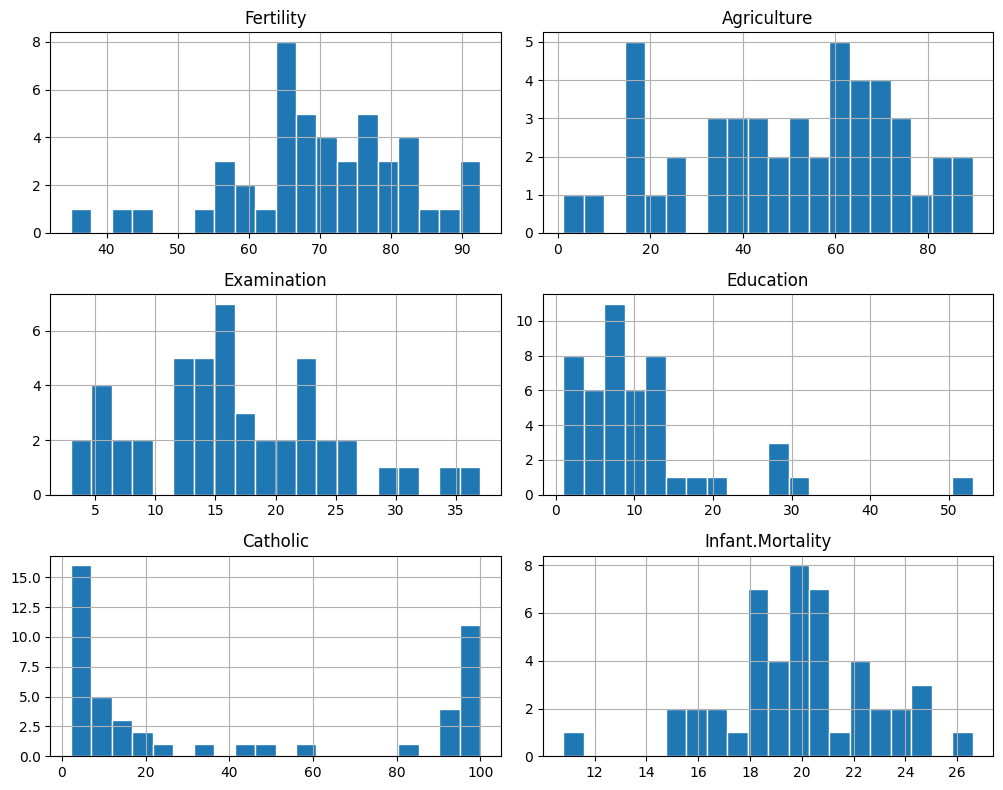

In [62]:
import matplotlib.pyplot as plt

# Genera una cuadrícula con el histograma de cada columna numérica
df.hist(figsize=(10, 8), bins=20, edgecolor='white')
plt.tight_layout()
plt.show()


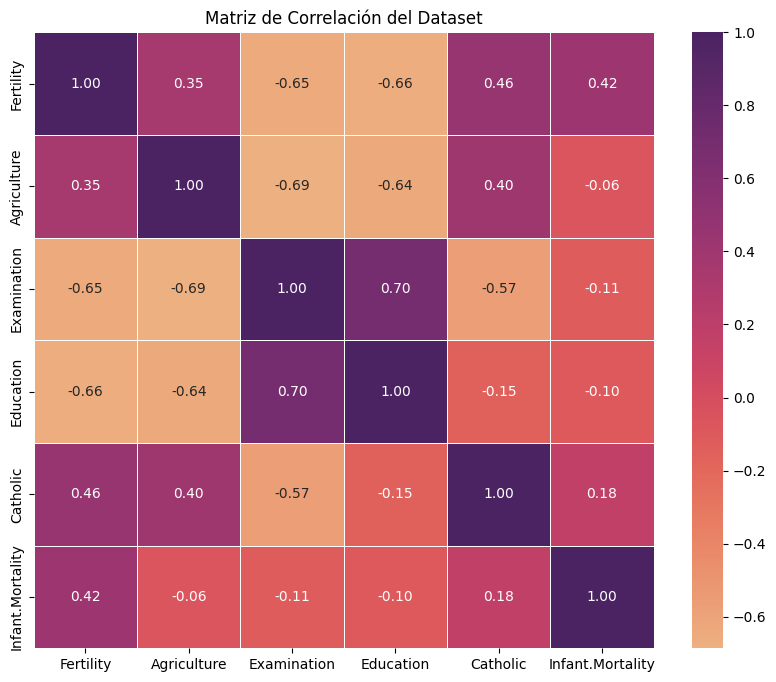

In [32]:
# Suponiendo que tu dataset se llama 'df'
# 1. Calculamos la matriz de correlación (solo de columnas numéricas)
corr = df.corr(numeric_only=True)

# 2. Creamos el mapa de calor
plt.figure(figsize=(10, 8)) # Ajusta el tamaño de la ventana
sns.heatmap(corr, annot=True, cmap='flare', fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación del Dataset')
plt.show()


In [49]:
# Calculamos la correlación cruzada
correlacion_swiss = df[["Location", "Fertility"]].corr()

plt.figure(figsize=(5, 3))
sns.heatmap(correlacion_swiss, annot=True, annot_kws={"size": 12}, fmt=".2f",
    cbar=True, cmap="cool")
plt.show()

ValueError: could not convert string to float: 'Courtelary'

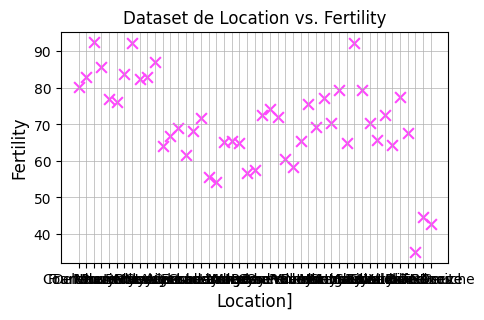

In [53]:
plt.figure(figsize=(5, 3))
plt.scatter(df['Location'], df['Fertility'], color='#ff48fd',
    marker="x", s=60)
plt.grid(True, linewidth=0.5)
plt.xlabel('Location]', fontsize=12)
plt.ylabel('Fertility', fontsize=12)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)
plt.title('Dataset de Location vs. Fertility', fontsize=12)
plt.show()

## Regresión lineal múltiple

Arranquemos la primera parte del ejercicio. Para eso, vamos a entrenar un modelo de regresión lineal múltiple usando todos los atributos. Para ello debes:

1. Escalar los atributos usando `StandardScaler`
2. Entrenar el modelo usando el dataset de entrenamiento.
3. Obtener las predicciones sobre el dataset de testeo.
4. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first') # Corra la columna 1 por estabilidad numérica
encoder.fit(df[["Location"]])
encoded_state = encoder.transform(df[["Location"]]).toarray()
encoded_state[:5, :]
encoded_columns = encoder.get_feature_names_out()
encoded_columns
encoded_df = pd.DataFrame(encoded_state, columns=encoded_columns)

# Unimos las columnas codificadas con el DataFrame original
dataset_with_dummies = pd.concat([df, encoded_df], axis=1)

# Lista de las columnas que SÍ quieres conservar
columnas_validas = ['Fertility', 'Agriculture', 'Examination', 'Education', 'Catholic', 'Infant.Mortality']

# Filtramos el DataFrame directamente
dataset_limpio = dataset_with_dummies[columnas_validas]

dataset_limpio.head()





,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
0,80.2,17.0,15,12,9.96,22.2
1,83.1,45.1,6,9,84.84,22.2
2,92.5,39.7,5,5,93.40,20.2
3,85.8,36.5,12,7,33.77,20.3
4,76.9,43.5,17,15,5.16,20.6


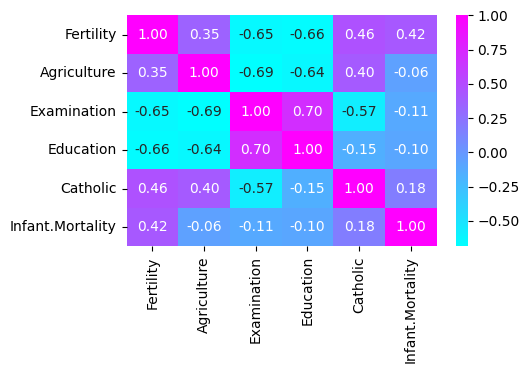

In [86]:
correlacion_profit = dataset_limpio.corr()

plt.figure(figsize=(5, 3))
sns.heatmap(correlacion_profit, annot=True, cmap='cool', annot_kws={"size": 10},
    fmt=".2f", cbar=True)
plt.show()

In [ ]:
# 1. Escalar los atributos usando `StandardScaler`


# 2. Entrenar el modelo usando el dataset de entrenamiento.


# 3. Obtener las predicciones sobre el dataset de testeo.


# 4. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.

## Modelo con regularización

Para mejorar nuestro modelo, vamos a explorar técnicas de regresión lineal con regularización, que nos permiten controlar el sobreajuste y seleccionar variables relevantes automáticamente.

Existen dos variantes muy populares:

- Una penaliza la suma de los cuadrados de los coeficientes (regularización L2).
- La otra penaliza la suma del valor absoluto de los coeficientes (regularización L1).

Ambas ayudan a mejorar la generalización, pero una de ellas además puede eliminar variables (coeficientes exactamente cero), lo que ayuda a identificar qué atributos son realmente importantes.

Tu tarea:

1. Elegí correctamente cuál de los dos métodos de regularización usar para este problema.
    - Pista: Queremos que el modelo sea capaz de hacer una selección automática de variables, dejando fuera aquellas que no aportan.
2. Implementá un pipeline que incluya escalado y el modelo elegido.
3. Buscá automáticamente el mejor valor del hiperparámetro de regularización (alpha) usando validación cruzada usando 3-folds.
4. Entrená el modelo con los datos de entrenamiento y obtené las predicciones para el set de testeo.
5. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.
6. Imprimí los coeficientes resultantes e identificá qué variables fueron eliminadas (coeficiente = 0).

In [ ]:
import numpy as np

from sklearn.linear_model import LassoCV, RidgeCV

Paremos un momento para entender qué hacen LassoCV y RidgeCV antes de continuar con la resolución:

> Tanto `LassoCV` como `RidgeCV` son implementaciones de regresión lineal con regularización que incluyen la búsqueda automática del mejor hiperparámetro alpha mediante validación cruzada.
>
> Ambos métodos prueban distintos valores de alpha y eligen el que minimiza el error del modelo, facilitando el proceso de ajuste sin necesidad de una búsqueda manual.
>
> Internamente, utilizan la métrica del error cuadrático medio (MSE) para evaluar el rendimiento del modelo en cada fold de la validación cruzada.
>
> Por ejemplo, si llamás a RidgeCV(alphas=alphas, cv=5), se hará una validación cruzada de 5 folds utilizando los valores de alpha que vos le pases, y se seleccionará el que obtenga el menor MSE promedio.
>
> Una vez elegido el mejor alpha, el modelo final se entrena con todos los datos de entrenamiento usando ese valor.

¡Listo! Con todo lo que vimos hasta ahora, ya estás en condiciones de resolver esta parte y completar los 6 puntos propuestos

In [ ]:
alphas = np.logspace(-4, 1, 500)

##### COMPLETAR AQUI LO PEDIDO



## Comparación de modelos y conclusiones

Completá la siguiente tabla con las métricas obtenidas para cada uno de los modelos que entrenaste:

| Modelo                        | MAE | MSE | $R^2$ |
| ----------------------------- | --- | --- | ----- |
| Regresión Lineal              |     |     |       |
| Modelo Regularizado (L1 o L2) |     |     |       |


> ⚠️ Asegurate de cambiar el nombre del modelo `Modelo Regularizado (L1 o L2)` según el modelo que usaste (Lasso o Ridge).

### Justificación

**¿Cuál de los modelos te parece que tuvo un mejor desempeño general?**

Tené en cuenta las tres métricas al responder, y también pensá en la complejidad del modelo (por ejemplo, si eliminó variables innecesarias).

Escribí tu respuesta a continuación:

ESCRIBA AQUI SU RESPUESTA